In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Car_sales.csv")

In [5]:
df.shape

(157, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    object 
 1   Model                157 non-null    object 
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    object 
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    object 
 15  Power_perf_factor    155 non-null    flo

In [9]:
(df['__year_resale_value'] / df['Price_in_thousands']).mean()

0.6819744262129059

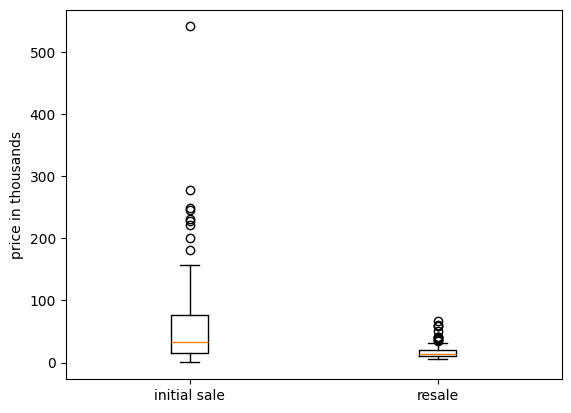

In [12]:
fig, ax = plt.subplots()
ax.set_ylabel('price in thousands')
 
bplot = ax.boxplot(df[["Sales_in_thousands","__year_resale_value"]].dropna(),
                  tick_labels = ['initial sale', 'resale'])  # will be used to label x-ticks
 

In [14]:
df.dropna(inplace=True)

In [15]:
# Get 3 most expensive cars
most_expensive_cars = df.nlargest(3, 'Price_in_thousands')
most_expensive_cars 

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
95,Mercedes-B,SL-Class,3.311,58.600,Passenger,82.60,5.0,302.0,99.0,71.3,177.1,4.125,21.1,20.0,3/17/2011,139.982294
126,Porsche,Carrera Cabrio,1.866,67.550,Passenger,74.97,3.4,300.0,92.6,69.5,174.5,3.075,17.0,23.0,7/11/2011,135.914710
125,Porsche,Carrera Coupe,1.280,60.625,Passenger,71.02,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,12/21/2012,134.390975


In [17]:
df.sort_values(by=['Price_in_thousands'],ascending=False).head(3)
# plot as a bar 5 Manufacturers

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
95,Mercedes-B,SL-Class,3.311,58.600,Passenger,82.60,5.0,302.0,99.0,71.3,177.1,4.125,21.1,20.0,3/17/2011,139.982294
126,Porsche,Carrera Cabrio,1.866,67.550,Passenger,74.97,3.4,300.0,92.6,69.5,174.5,3.075,17.0,23.0,7/11/2011,135.914710
125,Porsche,Carrera Coupe,1.280,60.625,Passenger,71.02,3.4,300.0,92.6,69.5,174.5,3.032,17.0,21.0,12/21/2012,134.390975


In [22]:
df.groupby(["Manufacturer"])["Sales_in_thousands"].sum()

Manufacturer
Acura           64.891
Audi            40.557
BMW             26.758
Buick          242.019
Cadillac        81.450
Chevrolet      446.370
Chrysler       117.545
Dodge          720.798
Ford          1846.965
Honda          592.674
Hyundai        137.326
Infiniti        23.713
Jeep           293.153
Lexus           43.145
Lincoln         62.709
Mercedes-B      66.079
Mercury        237.999
Mitsubishi     180.895
Nissan         280.472
Oldsmobile      60.180
Plymouth        62.129
Pontiac        330.962
Porsche         12.128
Saturn         110.389
Toyota         675.086
Volkswagen     159.749
Name: Sales_in_thousands, dtype: float64

<Axes: xlabel='Manufacturer', ylabel='sum'>

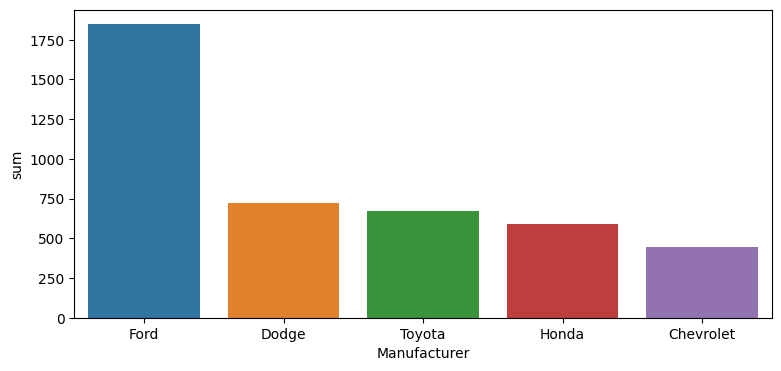

In [25]:
large5 = df.groupby(["Manufacturer"])["Sales_in_thousands"].sum().nlargest(5).reset_index(name="sum")
plt.figure(figsize=(9, 4))
sns.barplot( data=large5, x="Manufacturer", y="sum")
# large5

/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

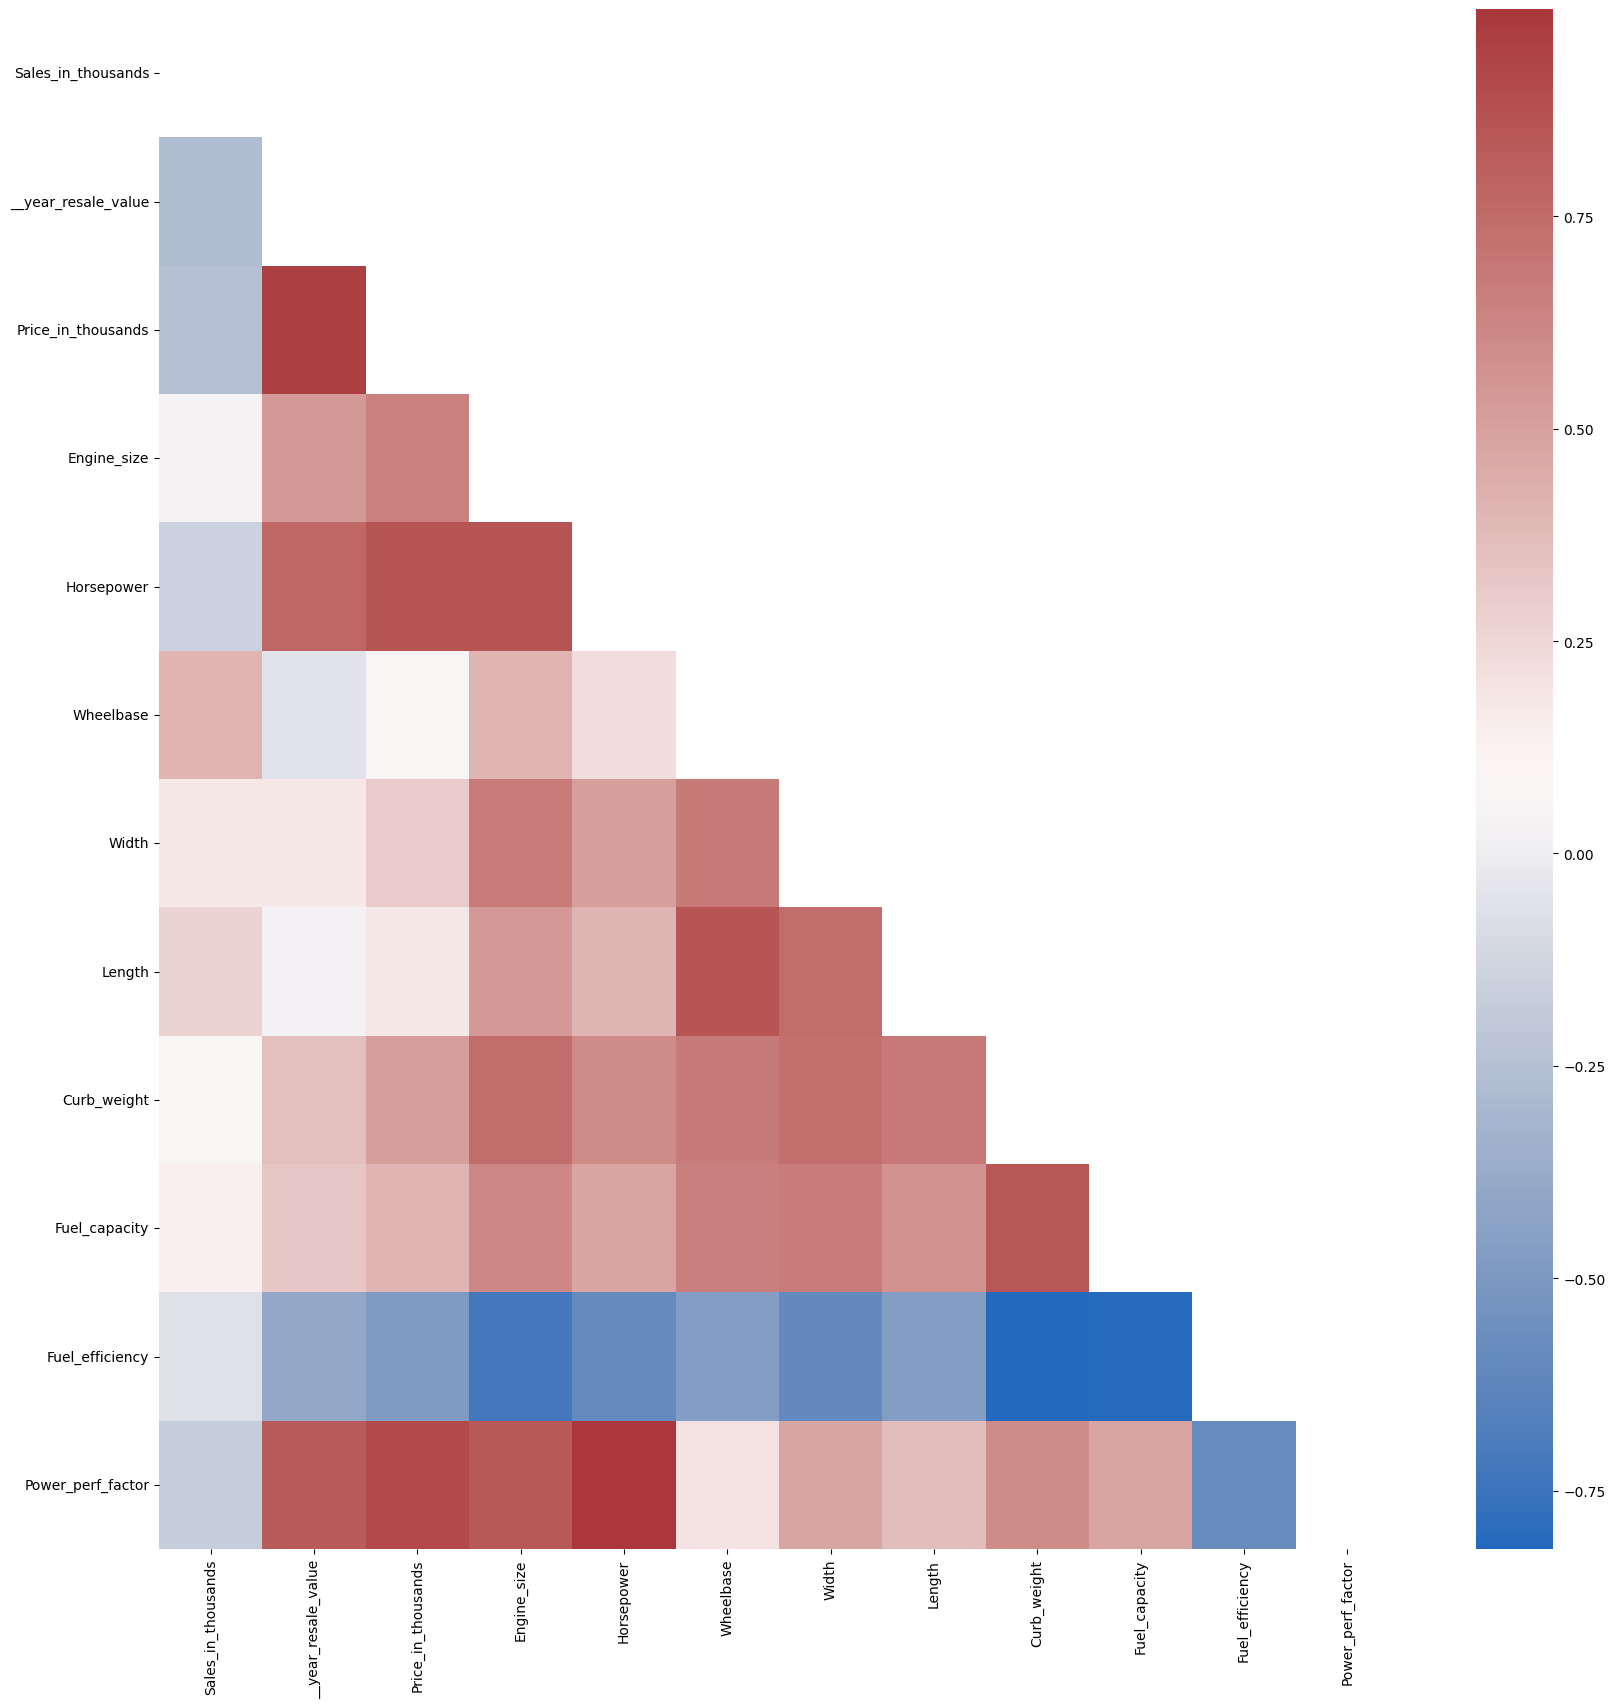

In [30]:
df_corr = df.corr(numeric_only=True)
mask = np.zeros_like(df_corr)
triangle_indicies = np.triu_indices_from(mask)
mask[triangle_indicies] = True
plt.figure(figsize=(20,20))
sns.heatmap(df_corr, annot=True,mask=mask, cmap = 'vlag')

In [31]:
df["Manufacturer"].nunique()

26

In [32]:
df["Manufacturer"].unique()

array(['Acura', 'Audi', 'BMW', 'Buick', 'Cadillac', 'Chevrolet',
       'Chrysler', 'Dodge', 'Ford', 'Honda', 'Hyundai', 'Infiniti',
       'Jeep', 'Lexus', 'Lincoln', 'Mitsubishi', 'Mercury', 'Mercedes-B',
       'Nissan', 'Oldsmobile', 'Plymouth', 'Pontiac', 'Porsche', 'Saturn',
       'Toyota', 'Volkswagen'], dtype=object)

In [34]:
price_mean = df.groupby('Manufacturer')['Price_in_thousands'].mean().sort_values(ascending=False)

In [37]:
price_mean.loc["BMW"]

36.15

In [38]:
price_mean.loc["Ford"]

21.920499999999997

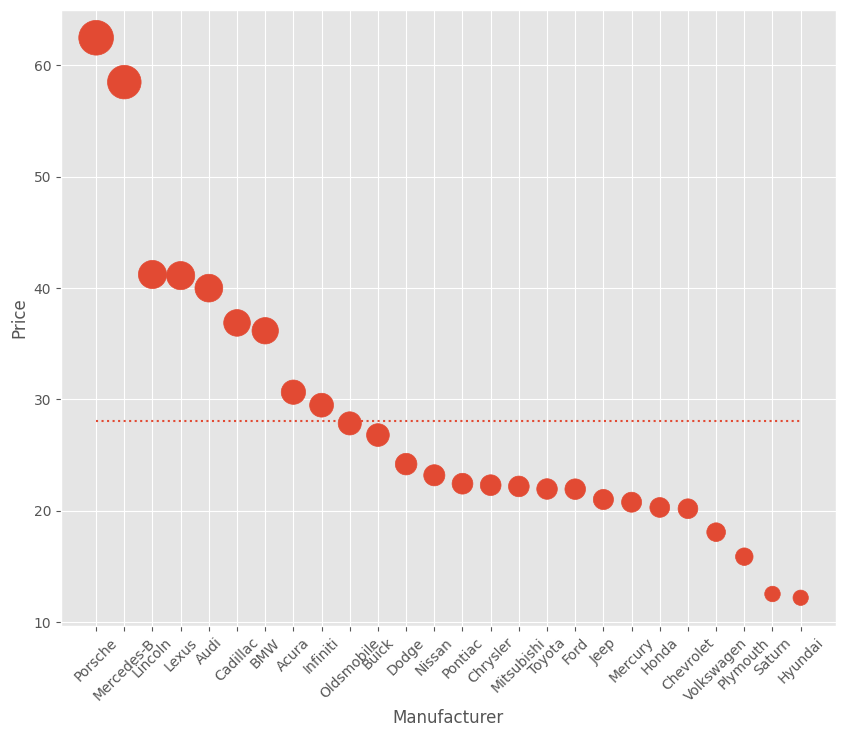

In [50]:
plt.figure(figsize=(10,8))
plt.style.use('ggplot')
plt.scatter(price_mean.index, 
            price_mean.values, 
            s=price_mean.values*10)
plt.hlines(price_mean.mean(),xmin="Porsche",xmax="Hyundai", 
           linestyles=":")
plt.xticks(rotation=45)
plt.xlabel("Manufacturer")
plt.ylabel("Price");